# NetVLAD 네트워크 설계해보기

샘플 이미지를 가져와서, NetVLAD의 Network가 어떤 연산을 거쳐가는지 확인해본다. 

연산의 종류는 3가지로 나뉜다.

1. Clustering :  
CNN을 통과한 feature descriptor를 K개의 Cluster로 분류하고,  
각 Cluster의 Centroid를 추출한다. 이를 통해 VLAD Vector를 정의하기 때문에, 먼저 수행해야 한다. 

2. VLAD Layer :   
soft assignment의 과정을 이해한다.  

3. def get_cluster, class netVLAD :  
VLAD Layer를 학습가능한 Network module로 패키징하여 CNN module에 add 한다. 


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
import torch.optim as optim
import torch.autograd as Variable


import torchvision
import torchvision.transforms as transforms
import torchvision.models as models


import os
from PIL import Image
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
from collections import namedtuple
import random

import sklearn
from sklearn.neighbors import NearestNeighbors


#test image Netvlad_vanila/data/Pittsburgh250k/000/000000_pitch1_yaw4.jpg
#test image Netvlad_vanila/data/Pittsburgh250k/000/000994_pitch2_yaw7.jpg


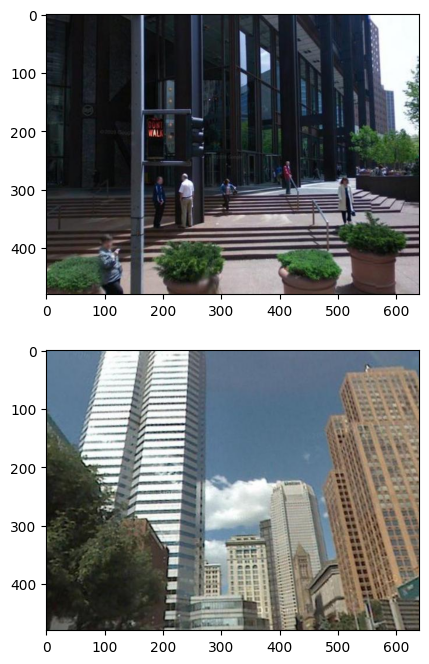

In [4]:
# 이미지를 보자. 

testImage1_path = './data/Pittsburgh250k/000/000000_pitch1_yaw4.jpg'
testImage2_path = './data/Pittsburgh250k/000/000994_pitch2_yaw7.jpg'

testImg1= Image.open(testImage1_path)
testImg2= Image.open(testImage2_path)

plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.imshow(testImg1)
plt.subplot(2,1,2)
plt.imshow(testImg2)


## CNN Network
feature를 추출하고, clustering을 수행한다. 

<figure style="text-align:center;">  <img src="2026-03-05-03-44-04.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-03-49-11.png" style="width:70%;"></figure>

In [117]:
#CNN Network 선언
#Class 시작
class VGG16Feature(nn.Module):
    def __init__(self):
        super().__init__()
        
        #encoder = models.vgg16(pretrained=True) 버전이 바뀌면서 워닝이 뜬다.
        encoder = models.vgg16(weights="VGG16_Weights.IMAGENET1K_FEATURES")
        # capture only feature part and remove last relu and maxpool
        layers = list(encoder.features.children())[:-2]
        
        self.encoder = nn.Sequential(*layers)
        self.encoder_dim = 512
    
    def forward(self, x):
        x = self.encoder(x)
        return x
#Class 끝 

#데이터 준비

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225]),
])

#배치를 만들어보려고 써봤다. 
x = torch.stack([
    transform(testImg1),
    transform(testImg2)
],dim=0)


#x = transform(testImg1).unsequeeze(0) #단일이미지용

print(x.shape)




cpu
torch.Size([2, 3, 480, 640])


In [118]:
#cuda 확인
if torch.cuda.is_available() :
    device = 'cuda'
else :
    device = 'cpu' 

#device = 'cpu' 호기심 테스트
print(device)

x = x.to(device)
model = VGG16Feature().to(device)
model.eval()

with torch.no_grad():
    feat=model(x)

print(feat.shape)
#고작 이미지2개인데, CPU 0.8초 GPU 0.4초 걸림

cuda
torch.Size([2, 512, 30, 40])


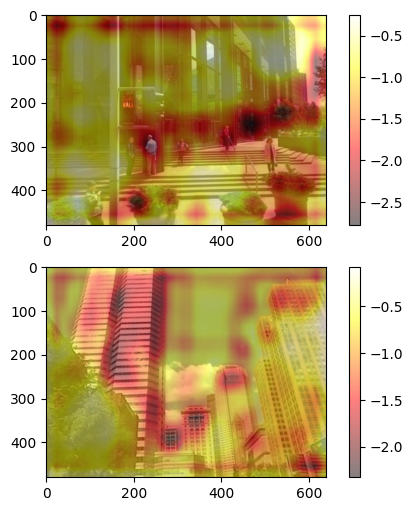

In [120]:
#시각화용 코드블럭

import torch.nn.functional as F
import matplotlib.pyplot as plt

# feat: (B, 512, 30, 40)
heat = feat.mean(dim=1)            # (B, 30, 40)  채널 평균으로 heatmap
heat1 = heat[0]                     # 첫 번째 이미지
heat2 = heat[1]

w,h = testImg1.size

# 원본 이미지 크기로 업샘플
heat1 = F.interpolate(
    heat1.unsqueeze(0).unsqueeze(0),  # (1,1,30,40)
    size=(h,w),        # (H,W)
    mode='bilinear',
    align_corners=False
).squeeze().cpu().numpy()

heat2 = F.interpolate(
    heat2.unsqueeze(0).unsqueeze(0),  # (1,1,30,40)
    size=(h,w),        # (H,W)
    mode='bilinear',
    align_corners=False
).squeeze().cpu().numpy()

plt.figure(figsize=(6,6))
plt.subplot(2,1,1)
plt.imshow(testImg1)               
plt.imshow(heat1,cmap='hot', alpha=0.5)  # heatmap overlay
plt.colorbar()

plt.subplot(2,1,2)
plt.imshow(testImg2)                
plt.imshow(heat2,cmap='hot', alpha=0.5)  # heatmap overlay
plt.colorbar()
plt.show()

#https://wikidocs.net/141538

In [128]:
import numpy as np
import torch.nn.functional as F

B, C, H, W = feat.shape
print(B)
print(C)
print(H)
print(W)

# (B,C,H,W) -> (B,H,W,C) -> (B*H*W, C)
X = feat.permute(0, 2, 3, 1).reshape(-1, C)

# vladv1 스타일: descriptor L2 normalize 
X = F.normalize(X, p=2, dim=1)
# 여기까지가 CNN 네트워크

X_np = X.detach().cpu().numpy()  #sklearn 쓰려면 Numpy로 돌려야 한다. detach()
print(f"X_np shape: {X_np.shape}")  # (B*H*W, C)
print(f"X_np dtype: {X_np.dtype}")

2
512
30
40
X_np shape: (2400, 512)
X_np dtype: float32


In [129]:
#https://sthsb.tistory.com/34

from sklearn.cluster import KMeans

K = 64
kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_np)           # (B*H*W,)
centroids = kmeans.cluster_centers_         # (K, C)

print(labels.shape, centroids.shape)
print(centroids.dtype)

(2400,) (64, 512)
float32


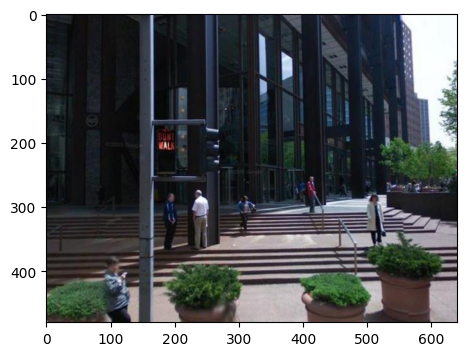

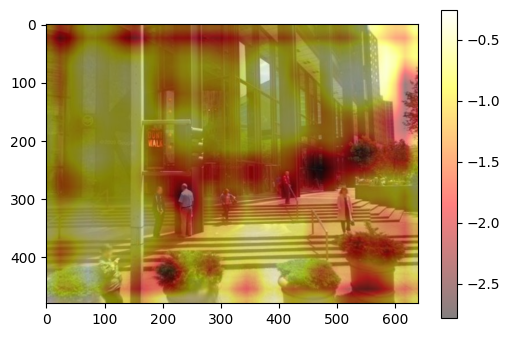

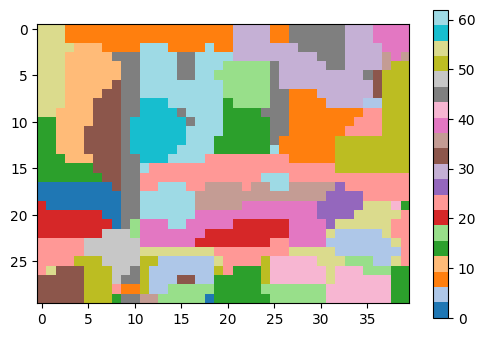

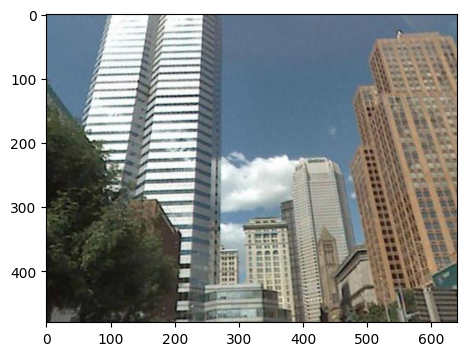

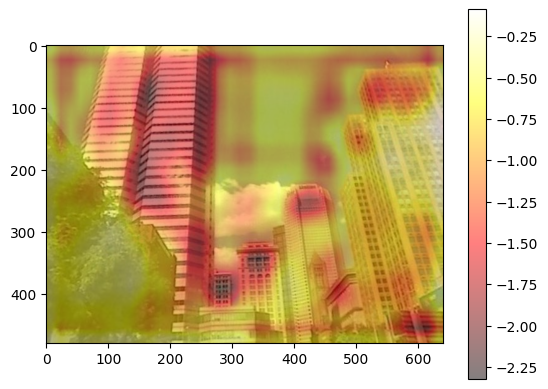

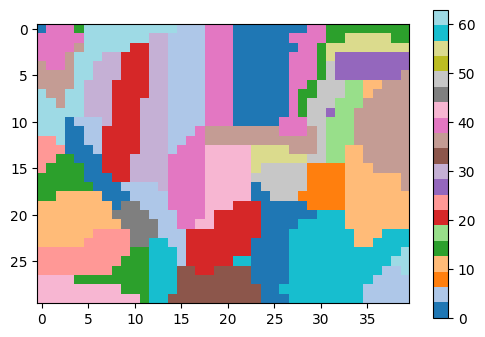

In [151]:
cluster_map = labels.reshape(B, H, W)  # (2,30,40)

plt.figure(figsize=(6,4))
plt.imshow(testImg1)
plt.show()

plt.figure(figsize=(6,4))

plt.imshow(testImg1)               
plt.imshow(heat1,cmap='hot', alpha=0.5)  # heatmap overlay
plt.colorbar()

plt.figure(figsize=(6,4))
plt.imshow(cluster_map[0], cmap='tab20')
plt.colorbar()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(testImg2)
plt.show()

plt.imshow(testImg2)               
plt.imshow(heat2,cmap='hot', alpha=0.5)  # heatmap overlay
plt.colorbar()

plt.figure(figsize=(6,4))
plt.imshow(cluster_map[1], cmap='tab20')
plt.colorbar()
plt.show()

## VLAD Layer

<figure style="text-align:center;">  <img src="2026-03-05-04-16-41.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-16-59.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-17-36.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-18-01.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-33-57.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-34-22.png" style="width:70%;"></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-41-10.png" style="width:70%;"></figure>

In [153]:
import torch
import torch.nn.functional as F

device = feat.device
print(device)

#descriptor와 cluster 중심점의 normalize
centroids_t = torch.tensor(centroids, dtype=feat.dtype, device=device)  # (K, C)

# vladv1: cosine 기반이므로 둘 다 L2 normalize
x = F.normalize(feat, p=2, dim=1)                 # (B,C,H,W)
centroids_nt = F.normalize(centroids_t, p=2, dim=1)          # (K,C)

cuda:0


<figure style="text-align:center;">  <img src="2026-03-05-10-01-50.png" ></figure>

<figure style="text-align:center;">  <img src="2026-03-05-10-02-04.png" ></figure>

In [201]:
#score 계산. 각위치의 descriptor (dot) cluster 중심점   -->dot product
B, C, H, W = x.shape
HW = H * W

x_flat = x.permute(0, 2, 3, 1).reshape(B, HW, C)     # (B,HW,C)
print(f"x_flat.shape : {x_flat.shape}")
print(f"c.shape : {centroids_nt.shape}")

# score[b,i,k] = alpha * dot(x_flat[b,i,:], c[k,:])
alpha = 2.0
weight_k = torch.matmul(x_flat, centroids_nt.t())            # (B,HW,K)
bias_k = alpha * centroids_t.norm(dim=1)
print(f"centroids_nt.t().shape : {centroids_nt.t().shape}")
scores = alpha * weight_k
scores_biased = alpha * weight_k + bias_k
print(f"scores.shape : {scores.shape}")
print(f"scores_biased.shape : {scores_biased.shape}")
#https://docs.pytorch.org/docs/stable/generated/torch.matmul.html
#https://velog.io/@passiona2z/%EC%9E%91%EC%84%B1%EC%A4%91-PyTorch-%ED%85%90%EC%84%9C%EA%B0%84%EC%9D%98-%EA%B3%B1%EC%85%88


x_flat.shape : torch.Size([2, 1200, 512])
c.shape : torch.Size([64, 512])
centroids_nt.t().shape : torch.Size([512, 64])
scores.shape : torch.Size([2, 1200, 64])
scores_biased.shape : torch.Size([2, 1200, 64])


<figure style="text-align:center;">  <img src="2026-03-05-04-50-42.png" ></figure>

<figure style="text-align:center;">  <img src="2026-03-05-04-51-05.png" ></figure>  


In [202]:
soft_assign = F.softmax(scores_biased, dim=2)   # (B,HW,K)
print(soft_assign.shape)

torch.Size([2, 1200, 64])


In [203]:
soft_assign_bkhw = soft_assign.permute(0, 2, 1)  # (B,K,HW)
print(soft_assign_bkhw.shape)

torch.Size([2, 64, 1200])


In [204]:
#연산 잘 되었는지 확인용
print(torch.allclose(soft_assign.sum(dim=2), torch.ones(B, HW, device=device), atol=1e-5))

True


In [205]:
# residual: (B, HW, K, C)
#type debugging
print(x_flat.shape)
print(x_flat.dtype)
print(x_flat.unsqueeze(2).shape)
print(centroids_nt.shape)
print(centroids_nt.dtype)
print(centroids_nt.unsqueeze(0).unsqueeze(0).shape)


residual = x_flat.unsqueeze(2) - centroids_nt.unsqueeze(0).unsqueeze(0) #broadcasting

print(residual.shape)

torch.Size([2, 1200, 512])
torch.float32
torch.Size([2, 1200, 1, 512])
torch.Size([64, 512])
torch.float32
torch.Size([1, 1, 64, 512])
torch.Size([2, 1200, 64, 512])


In [206]:
# weighted_residual: (B, HW, K, C)
soft_assign2 = soft_assign
print(soft_assign2.unsqueeze(3).shape)
weighted_residual = residual * soft_assign.unsqueeze(3)  #broadcasting
print(weighted_residual.shape)

torch.Size([2, 1200, 64, 1])
torch.Size([2, 1200, 64, 512])


In [207]:
vlad3d = weighted_residual.sum(dim=1)
vlad3d = F.normalize(vlad3d, p=2, dim=2)       # intra (C 방향), cluster bias제거 목적
vlad = vlad3d.reshape(B, -1)                   # (B, K*C)
vlad = F.normalize(vlad, p=2, dim=1)           # global (KD 방향)
print(vlad.shape)


torch.Size([2, 32768])


-2.7939677e-09


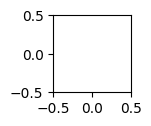

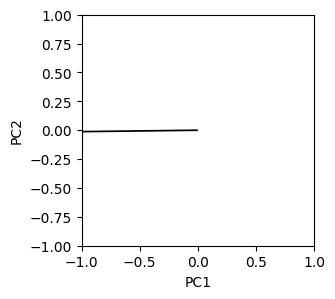

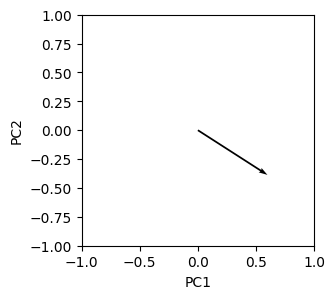

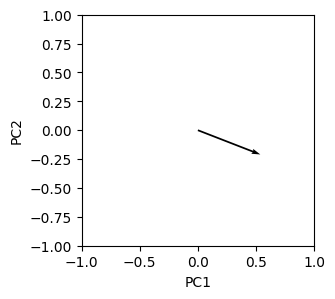

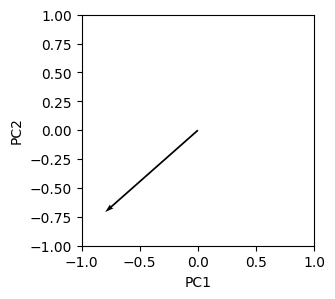

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# vlad3d: (B, K, C)
v = vlad3d[0].detach().cpu().numpy()   # (64, 512)

pca = PCA(n_components=2, random_state=0)
v2 = pca.fit_transform(v)              # (64, 2)
print(v2.mean())
plt.figure(figsize=(1,1))
# plt.figure(figsize=(6,6))
plt.xlim([-0.5, 0.5])      # X축의 범위: [xmin, xmax]
plt.ylim([-0.5, 0.5])     # Y축의 범위: [ymin, ymax]
for k in range(4):

    #plt.text(v2[k,0], v2[k,1], str(k), fontsize=8)
    plt.figure(figsize=(3,3))
    plt.xlim([-1, 1])      # X축의 범위: [xmin, xmax]
    plt.ylim([-1, 1])     # Y축의 범위: [ymin, ymax]

    plt.quiver(0,0,v2[k,0], v2[k,1],scale=1)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    #plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# plt.quiver(
#     np.zeros(64), np.zeros(64),   # 시작점
#     v2[:,0], v2[:,1],             # 벡터
#     angles='xy',
#     scale_units='xy',
#     scale=1
# )
    
# plt.xlabel("PC1"); plt.ylabel("PC2")
# #plt.gca().set_aspect('equal', adjustable='box')
# plt.show()

In [209]:
print(vlad)

tensor([[-0.0020,  0.0014, -0.0051,  ..., -0.0049, -0.0134,  0.0069],
        [ 0.0002,  0.0019, -0.0059,  ..., -0.0063, -0.0119,  0.0072]],
       device='cuda:0')


In [210]:
sim = (vlad[0] * vlad[1]).sum().item()  #  dot = cosine
sim2 = torch.norm(vlad[0]-vlad[1])
print(sim)
print(sim2)

0.8854928016662598
tensor(0.4786, device='cuda:0')


In [232]:
from math import log10, ceil
from torch.utils.data import DataLoader, SubsetRandomSampler


nDesrciptor = 50000
nPerImages = 100
nIm = ceil(nDesrciptor / nPerImages)
sampler = SubsetRandomSampler(np.random.choice(100000, nIm, replace=False))
#print(type(sampler))
#print(np.random.choice(100000, nIm, replace=False))
print(len(sampler))


500


In [240]:
def getCluster(mymodel,datasets,K=64):

    #Parameter Initialize
    #테스트용 코드 작성과는 다르게, Ref.코드에서는 이미지 100개에서, 5만개의 Desciptor를 샘플링한다. 
    #따라서, 데이터셋에서 100개의 이미지를 랜덤샘플하고, 여기서 각각 500개의 descriptor를 추출해서 Clustering을 진행한다. 
    #https://m.blog.naver.com/kwangrok21/222412219800 SubsetRandomSampler 사용법법

    from math import ceil
    from torch.utils.data import SubsetRandomSampler
    import numpy as np
    from sklearn.cluster import KMeans

    nDesrciptor = 50000
    nPerImages = 100
    nIm = ceil(nDesrciptor / nPerImages)
    sampler = SubsetRandomSampler(np.random.choice(len(datasets), nIm, replace=False))

    data_loader = DataLoader(dataset=datasets, num_workers=4, sampler=sampler)

    mymodel.eval()
    with torch.no_grad():
        feat = mymodel(data_loader)

    X = feat.permute(0, 2, 3, 1).reshape(-1, C)
    X = F.normalize(X, p=2, dim=1)
    X_np = X.detach().cpu().numpy()  #sklearn 쓰려면 Numpy로 돌려야 한다. detach()

    kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
    #labels = kmeans.fit_predict(X_np)           # (B*H*W,) debug, 시각화용. 
    centroids = kmeans.cluster_centers_         # (K, C)
    
    return centroids
    
    # 이건 getCluster사용하기 전에 먼저 할 것. 
    # x = x.to(device)
    # model = VGG16Feature().to(device)
    
    


In [ ]:
class NetVLAD(nn.Module):
    

In [ ]:
#

model = nn.Module() 
model.add_module('encoder', VGG16Feature)
model.add_module('pool', NetVLAD)


